In [2]:
import sys
!{sys.executable} -m pip install opencv-python easyocr pandas

In [3]:
import re
import cv2
import easyocr
import pandas as pd
from pathlib import Path

In [4]:
def crop_top_left_banner(frame):
    """
    左上の map / current / decider が表示される帯を切り出す
    返り値: cropped image
    """
    h, w = frame.shape[:2]

    y1 = 0
    y2 = int(h * 0.03) 
    x1 = 0
    x2 = int(w * 0.35)   

    crop = frame[y1:y2, x1:x2]
    return crop

In [5]:
def preprocess_for_ocr(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

    _, th = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

    return th

In [6]:
VALID_MAPS = {
    "ASCENT", "BIND", "SPLIT", "HAVEN", "PEARL",
    "LOTUS", "SUNSET", "ABYSS", "BREEZE", "ICEBOX", "FRACTURE", "CORRODE"
}

def normalize_text(text):
    text = text.upper()
    text = text.replace("|", "I")
    text = text.replace(";", ":")
    text = text.replace(".", ":")
    return text

def extract_current_map(ocr_text):
    """
    OCR文字列から CURRENT: MAPNAME を抜く
    """
    text = normalize_text(ocr_text)

    # まず CURRENT: XXX を探す
    m = re.search(r"CURRENT\s*:\s*([A-Z]+)", text)
    if m:
        cand = m.group(1)
        if cand in VALID_MAPS:
            return cand

    # CURRENT が読めないときでも map名が文中にある場合に拾う緩い版
    for mp in VALID_MAPS:
        if f"CURRENT: {mp}" in text or f"CURRENT {mp}" in text:
            return mp

    return None

In [7]:
def read_current_map_from_frame(frame, reader):
    crop = crop_top_left_banner(frame)
    proc = preprocess_for_ocr(crop)

    results = reader.readtext(proc, detail=0)
    ocr_text = " ".join(results)

    current_map = extract_current_map(ocr_text)

    return {
        "current_map": current_map,
        "ocr_text": ocr_text,
        "crop": crop,
        "proc": proc
    }

In [8]:
img_path = Path(r"..\data\samples\bind.png")   
frame = cv2.imread(img_path)

reader = easyocr.Reader(["en"], gpu=False)
result = read_current_map_from_frame(frame, reader)

print("OCR TEXT:", result["ocr_text"])
print("CURRENT MAP:", result["current_map"])

Using CPU. Note: This module is much faster with a GPU.


OCR TEXT: PEARL 12-14 CURRENT: BIND  DECIDER: SPLIT
CURRENT MAP: BIND


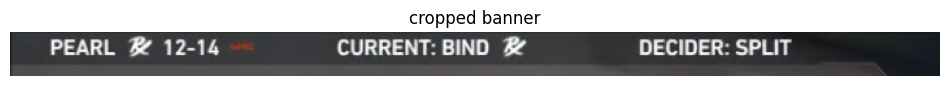

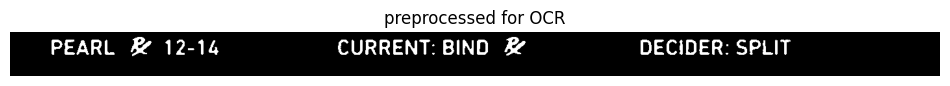

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.imshow(cv2.cvtColor(result["crop"], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("cropped banner")
plt.show()

plt.figure(figsize=(12, 3))
plt.imshow(result["proc"], cmap="gray")
plt.axis("off")
plt.title("preprocessed for OCR")
plt.show()

In [10]:
def scan_video_current_map(video_path, reader,sample_every_sec=5, max_samples=None):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames / fps


    rows = []
    t = 0.0
    sample_count = 0

    while t < duration_sec:
        frame_idx = int(t * fps)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        ok, frame = cap.read()
        if not ok:
            t += sample_every_sec
            continue

        result = read_current_map_from_frame(frame, reader)

        rows.append({
            "t_sec": round(t, 2),
            "current_map": result["current_map"],
            "ocr_text": result["ocr_text"]
        })

        sample_count += 1
        if max_samples is not None and sample_count >= max_samples:
            break

        t += sample_every_sec

    cap.release()
    return pd.DataFrame(rows)

In [11]:
reader = easyocr.Reader(["en"], gpu=True)
video_path = Path("../data/vods/M8 vs. EDG - VALORANT Masters Santiago - SWISS.mp4")
df = scan_video_current_map(video_path=video_path,reader=reader)

KeyboardInterrupt: 

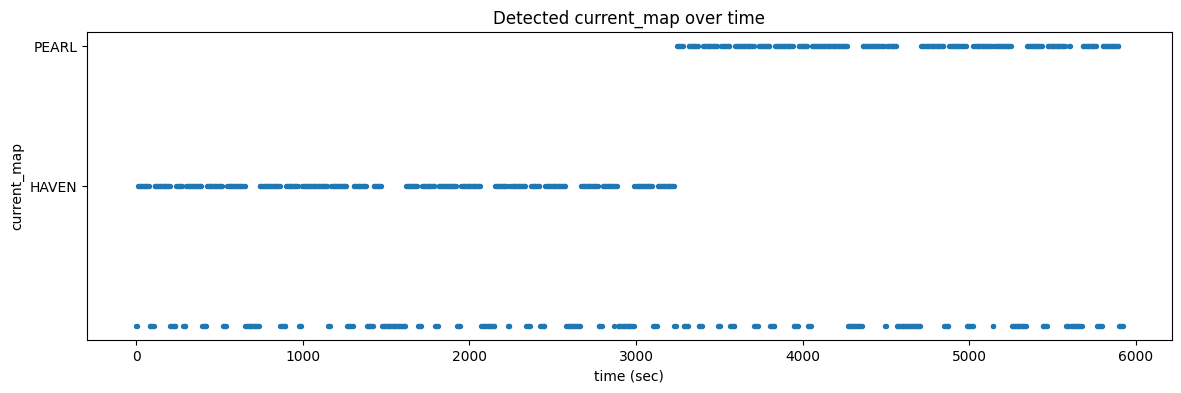

In [ ]:
plot_df = df.copy()

plot_df["map_code"] = plot_df["current_map"].astype("category").cat.codes
map_categories = list(plot_df["current_map"].astype("category").cat.categories)

plt.figure(figsize=(14, 4))
plt.scatter(plot_df["t_sec"], plot_df["map_code"], s=8)
plt.yticks(range(len(map_categories)), map_categories)
plt.xlabel("time (sec)")
plt.ylabel("current_map")
plt.title("Detected current_map over time")
plt.show()

In [ ]:
def extract_map_ranges_by_first_last(
    df: pd.DataFrame,
    time_col: str = "t_sec",
    map_col: str = "current_map",
    valid_maps: set[str] = VALID_MAPS,
    max_maps: int = 5,
) -> pd.DataFrame:
    work = df[[time_col, map_col]].copy()
    work = work[work[map_col].isin(valid_maps)].copy()

    if work.empty:
        return pd.DataFrame(columns=[
            "map_no", "map_name", "map_start_sec", "map_end_sec"
        ])

    order = work[map_col].drop_duplicates().tolist()[:max_maps]

    rows = []
    for i, m in enumerate(order, start=1):
        sub = work[work[map_col] == m]
        rows.append({
            "map_no": i,
            "map_name": m,
            "map_start_sec": sub[time_col].min(),
            "map_end_sec": sub[time_col].max(),
        })

    return pd.DataFrame(rows)

In [ ]:
extract_map_ranges_by_first_last(df)

,map_no,map_name,map_start_sec,map_end_sec
0,1,HAVEN,10.0,3225.0
1,2,PEARL,3245.0,5895.0


In [ ]:
df_path = Path("../data/samples/map_df.csv")
df.to_csv(df_path)

In [ ]:
df

NameError: name 'df' is not defined